# Medical Insurance Cost Prediction

In [4]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LassoLars
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [5]:
data = pd.read_csv('./insurance.csv')

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
data.info()
data.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

In [7]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
encoded_data = pd.get_dummies(data,columns=[
    "sex",
    "smoker",
    "region"
])

encoded_data.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [9]:
train_data, test_data = train_test_split(encoded_data, test_size=0.2,random_state=42)

train_data_x = train_data.drop('charges',axis=1)

train_data_y = train_data['charges']

test_data_x = test_data.drop('charges',axis=1)
test_data_y = test_data['charges']  

{'whiskers': [<matplotlib.lines.Line2D at 0x18d36150290>,
 'caps': [<matplotlib.lines.Line2D at 0x18d36150740>,
 'boxes': [<matplotlib.lines.Line2D at 0x18d3611ff80>],
 'medians': [<matplotlib.lines.Line2D at 0x18d36150da0>],
 'fliers': [<matplotlib.lines.Line2D at 0x18d361510d0>],
 'means': []}

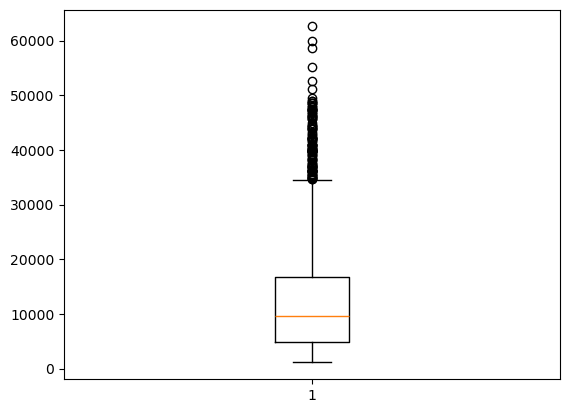

In [10]:
plt.boxplot(train_data_y)

In [11]:
scaler = StandardScaler()
scale_pattern = scaler.fit(train_data_x)
scaled_train_data_x = scale_pattern.transform(train_data_x)
scaled_test_data_x = scale_pattern.transform(test_data_x)

In [12]:
model = LassoLars()
model.fit(scaled_train_data_x,train_data_y)
predictions = model.predict(scaled_test_data_x)

# auc = accuracy_score(test_data_y, predictions)
mse =  mean_squared_error(test_data_y, predictions)
rmse = np.sqrt(mse)
r2 =  r2_score(test_data_y, predictions)

# print(f"auc: {auc}")
print(f"mse: {mse}")
print(f"rmse: {rmse}")
print(f"r2: {r2}")

mse: 33601293.15152237
rmse: 5796.662242318623
r2: 0.7835647813115763


In [13]:
print(model.coef_)

[ 3.61413988e+03  2.03480614e+03  5.15982890e+02  0.00000000e+00
 -8.14167901e+00 -9.55732140e+03  0.00000000e+00  2.82784689e+02
  1.20663476e+02  0.00000000e+00 -6.57162744e+01]
